# Hospital Readmission Risk Predictor — Notebook 4: Hyperparameter Tuning, Model Evaluation & Unsupervised Analysis

**Prepared for:** Hospital Administration & Care Management Stakeholders
**Prepared by:** Angeline Setiawan | **Team:** Epsilon
**Project:** Hospital Readmission Risk Predictor — A Phased MLOps Project

## Purpose

This notebook covers three modeling tasks on the same Phase 2 patient-level dataset (no new data sourcing is required):

1. **Supervised model, tuned.** Hyperparameter search across logistic regression, random forest, and XGBoost using the training partition only, selecting the candidate with the best cross-validated PR-AUC. This is the model that will eventually be registered in MLflow and served through FastAPI.
2. **Unsupervised model 1: K-means clustering.** Groups patients into risk-profile segments based on utilization, treatment-intensity, and demographic features, then checks whether any segment shows a materially different 30-day readmission rate.
3. **Unsupervised model 2: PCA (with an optional t-SNE view).** Reduces the 50+ engineered features down to a handful of components, both to visualize whether patients separate into natural groups and to evaluate whether the leading components are worth feeding into the supervised model as engineered features.

The two unsupervised analyses are exploratory: they inform feature engineering and patient-segmentation insight but do not themselves feed the MLflow / FastAPI / Airflow pipeline, which continues to serve only the single tuned supervised classifier.

This notebook continues directly from `03_Baseline_Models.ipynb`. It reuses the same Phase 2 train/test split and the same preprocessing pattern (median-impute + scale for numeric, missing-impute + one-hot for categorical, fit only on training data inside a pipeline) so that results are directly comparable to the baseline.


## 1. Imports and Reproducibility

Everything that touches randomness (train/validation splits inside CV, model initialization, K-means initialization) is seeded from a single `RANDOM_STATE` so results are reproducible run to run.


In [1]:
# ----------------------------------------------------------------------
# 1.1 Imports
# ----------------------------------------------------------------------
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_predict,
)
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    silhouette_score,
)
from sklearn.inspection import permutation_importance

# XGBoost is an optional dependency; fall back gracefully if it is not installed.
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("xgboost is not installed. Run `pip install xgboost` to include it in the search. "
          "The notebook will continue using logistic regression and random forest only.")

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# ----------------------------------------------------------------------
# Fast-mode toggle: run once with FAST_MODE = True to confirm the whole
# notebook runs end-to-end and to get a real per-stage runtime baseline
# on your machine before committing to the full search. Flip to False
# for the real run once Stage 2/3 timings look reasonable.
# ----------------------------------------------------------------------
FAST_MODE = False

if FAST_MODE:
    N_SPLITS = 3
    N_SEARCH_ITER = 8
else:
    N_SPLITS = 5
    N_SEARCH_ITER = 25  # RandomizedSearchCV draws per model family; raise for a more exhaustive search

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

print("Imports loaded.")


Imports loaded.


## 1.2 Progress and Timing Utilities

The hyperparameter searches, the out-of-fold threshold sweep, permutation importance, the K-means k-selection sweep, and the PCA/t-SNE steps are the most compute-intensive parts of this notebook and can each run for several minutes depending on hardware. The utilities below add a live progress bar and a stage timer around each of these steps so it is clear, at a glance, which step is currently running and how long it is taking. **These utilities are purely operational** — they do not change any model, metric, or saved artifact in this notebook.

Each major step is labeled `Stage X of 12` as it runs and reports its own elapsed time when it finishes. Total end-to-end notebook runtime is reported in Section 14, which is useful context when this notebook is later scheduled as a recurring Airflow job.


In [2]:
# ----------------------------------------------------------------------
# 1.2 Progress bars and stage timers
# ----------------------------------------------------------------------
# Purely operational utilities: they make it possible to see, at a glance,
# which step of the notebook is currently running and how long it is
# taking. Nothing in this cell touches modeling logic, so it is safe to
# reuse as-is in future notebooks in this project.
import time
from datetime import timedelta
from contextlib import contextmanager

try:
    from tqdm.auto import tqdm
except ImportError as exc:
    raise ImportError(
        "This notebook uses tqdm to render progress bars. "
        "Run `pip install tqdm` and re-run this cell."
    ) from exc

import joblib

# Wall-clock time the notebook started running; used at the very end
# (Section 14) to report total end-to-end runtime.
NOTEBOOK_START_TIME = time.time()

# Total number of "major stages" tracked below, used only for the
# human-readable "Stage X of TOTAL_STAGES" label printed at each step.
# Update this if stages are added or removed.
TOTAL_STAGES = 12
_stage_counter = {"current": 0}


def format_elapsed(seconds):
    """Render a duration in seconds as a short, human-readable string."""
    if seconds < 1:
        return f"{seconds:.2f}s"
    return str(timedelta(seconds=round(seconds)))


@contextmanager
def stage_timer(label):
    """
    Announce the start of a notebook stage, time it, and report elapsed
    time when it finishes. Advances a module-level stage counter each
    time it is used, so stages are numbered in the order they actually run.

    Usage:
        with stage_timer("Random forest hyperparameter search"):
            rf_search.fit(X_train, y_train)
    """
    _stage_counter["current"] += 1
    stage_num = _stage_counter["current"]
    start = time.time()
    print(f"\n{'=' * 78}")
    print(f"STAGE {stage_num}/{TOTAL_STAGES}: {label}")
    print(f"{'=' * 78}")
    try:
        yield
    finally:
        elapsed = time.time() - start
        print(f"Stage {stage_num}/{TOTAL_STAGES} complete — {label} "
              f"[{format_elapsed(elapsed)}]")


@contextmanager
def tqdm_joblib(tqdm_object):
    """
    Route joblib's internal completion callbacks into a tqdm progress bar.

    RandomizedSearchCV, cross_val_predict, and permutation_importance all
    run with n_jobs=-1 under the hood, which normally goes silent until the
    whole parallel job finishes. This context manager patches joblib so
    each completed unit of work (one CV fit, one fold, one feature) ticks
    the given tqdm bar forward instead.
    """
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    original_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = original_callback
        tqdm_object.close()


print(f"Progress/timing utilities loaded. Stages will be labeled "
      f"'Stage X of {TOTAL_STAGES}' as the notebook runs.")


Progress/timing utilities loaded. Stages will be labeled 'Stage X of 12' as the notebook runs.


## 2. File Paths and Load the Phase 2 Split

This reuses the exact train/test files produced in Phase 2 and consumed by the baseline notebook, so tuned-model results are directly comparable to the baseline results already reported.


In [3]:
# ----------------------------------------------------------------------
# 2.1 Locate the processed Phase 2 datasets
# ----------------------------------------------------------------------
CANDIDATE_TRAIN_PATHS = [
    "../data/processed/train.csv",
    "data/processed/train.csv",
]
CANDIDATE_TEST_PATHS = [
    "../data/processed/test.csv",
    "data/processed/test.csv",
]

def first_existing(paths):
    for path in paths:
        if os.path.exists(path):
            return path
    return None

TRAIN_PATH = first_existing(CANDIDATE_TRAIN_PATHS)
TEST_PATH = first_existing(CANDIDATE_TEST_PATHS)

if TRAIN_PATH is None or TEST_PATH is None:
    raise FileNotFoundError(
        "Could not find train.csv/test.csv. Expected them in "
        "../data/processed/ or data/processed/. "
        "Update TRAIN_PATH and TEST_PATH if your repository layout differs."
    )

# ----------------------------------------------------------------------
# 2.2 Load the datasets (timed: Stage 1/12)
# ----------------------------------------------------------------------
with stage_timer("Loading Phase 2 train/test datasets"):
    train_df = pd.read_csv(TRAIN_PATH)
    test_df = pd.read_csv(TEST_PATH)

    print(f"Training data: {train_df.shape[0]:,} rows x {train_df.shape[1]:,} columns")
    print(f"Testing data:  {test_df.shape[0]:,} rows x {test_df.shape[1]:,} columns")
    print(f"Training file: {TRAIN_PATH}")
    print(f"Testing file:  {TEST_PATH}")



STAGE 1/12: Loading Phase 2 train/test datasets
Training data: 52,829 rows x 58 columns
Testing data:  17,610 rows x 58 columns
Training file: ../data/processed/train.csv
Testing file:  ../data/processed/test.csv
Stage 1/12 complete — Loading Phase 2 train/test datasets [0.60s]


In [4]:
# ----------------------------------------------------------------------
# 2.2 Load Phase 3 baseline metrics for side-by-side comparison, if available
# ----------------------------------------------------------------------
BASELINE_METRICS_CANDIDATES = ["../outputs/baseline_test_metrics.csv", "outputs/baseline_test_metrics.csv"]
BASELINE_METRICS_PATH = first_existing(BASELINE_METRICS_CANDIDATES)

if BASELINE_METRICS_PATH is not None:
    baseline_test_metrics = pd.read_csv(BASELINE_METRICS_PATH)
    print(f"Loaded baseline metrics from {BASELINE_METRICS_PATH} for comparison in Section 9.")
    display(baseline_test_metrics)
else:
    baseline_test_metrics = None
    print("Baseline metrics file not found. Section 9's comparison table will show tuned-model results only.")


Loaded baseline metrics from outputs/baseline_test_metrics.csv for comparison in Section 9.


,Metric,Test Score
0,PR-AUC,0.108321
1,ROC-AUC,0.604588
2,Precision,0.300000
3,Recall,0.002498
4,F1,0.004955
5,Accuracy,0.931573


## 3. Define the Modeling Features

The feature set and exclusions are identical to `03_Baseline_Models.ipynb` so the tuned model is evaluated on the same information the baseline had access to. `patient_nbr`, `encounter_id`, and `encounter_order` are identifiers/ordering aids rather than predictors; the raw diagnosis codes are excluded in favor of the grouped `diag_x_group` fields; and the discharge-disposition fields are excluded because the intended use case is a risk score generated around admission, before discharge planning is known.


In [5]:
# ----------------------------------------------------------------------
# 3.1 Exclude identifiers, ordering aids, and leakage-risk columns
# ----------------------------------------------------------------------
TARGET = "readmitted_30d"

EXCLUDED_COLUMNS = (
    ["patient_nbr", "encounter_id", "encounter_order"]
    + ["diag_1", "diag_2", "diag_3"]
    + ["discharge_disposition_id", "discharge_disposition_id_label"]
    + [TARGET]
)

FEATURE_COLUMNS = [c for c in train_df.columns if c not in EXCLUDED_COLUMNS]

X_train = train_df[FEATURE_COLUMNS].copy()
X_test = test_df[FEATURE_COLUMNS].copy()
y_train = train_df[TARGET].astype(int).copy()
y_test = test_df[TARGET].astype(int).copy()

print(f"Number of modeling features before encoding: {len(FEATURE_COLUMNS)}")


Number of modeling features before encoding: 49


In [6]:
# ----------------------------------------------------------------------
# 3.2 Identify numeric and categorical variables
# ----------------------------------------------------------------------
NUMERIC_FEATURES = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
CATEGORICAL_FEATURES = [c for c in X_train.columns if c not in NUMERIC_FEATURES]

print(f"Numeric features: {len(NUMERIC_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")


Numeric features: 10
Categorical features: 39


## 4. Preprocessing Pipeline

Same pattern as the baseline: numeric variables are median-imputed and standardized, categorical variables are imputed to an explicit `"Missing"` category and one-hot encoded, and unknown test-set categories are ignored rather than raising an error. All parameters are learned inside the pipeline, and inside each cross-validation fold, so nothing is fit on data the model should not see yet.


In [7]:
# ----------------------------------------------------------------------
# 4.1 Build preprocessing transformer
# ----------------------------------------------------------------------
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, NUMERIC_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

cv_splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print("Preprocessing pipeline and CV splitter created.")


Preprocessing pipeline and CV splitter created.


# 5. Supervised Model: Hyperparameter Tuning

Three model families are searched: regularized logistic regression (the baseline's own family, now tuned), random forest, and XGBoost. Each search uses `RandomizedSearchCV` with **PR-AUC (average precision) as the scoring metric**, consistent with the baseline report's justification that ROC-AUC alone can look favorable even when minority-class performance is weak. All searches run 5-fold stratified cross-validation **on the training partition only**; the test set remains untouched until Section 9.

`class_weight="balanced"` is included as a tuned hyperparameter (not assumed) for logistic regression and random forest, and `scale_pos_weight` is included for XGBoost, so that the search itself can decide whether class weighting earns its way into the final model rather than being applied by default.


In [8]:
# ----------------------------------------------------------------------
# 5.1 Logistic regression search space
# ----------------------------------------------------------------------
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(solver="liblinear", max_iter=2000, random_state=RANDOM_STATE)),
])

logreg_param_dist = {
    "model__C": np.logspace(-3, 2, 50),
    "model__penalty": ["l1", "l2"],
    "model__class_weight": [None, "balanced"],
}

logreg_search = RandomizedSearchCV(
    estimator=logreg_pipeline,
    param_distributions=logreg_param_dist,
    n_iter=N_SEARCH_ITER,
    scoring="average_precision",
    cv=cv_splitter,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=0,  # progress is shown via the tqdm bar below instead
)

# ----------------------------------------------------------------------
# 5.1.1 Run the search (timed: Stage 2/12), with a live per-fit progress bar
# ----------------------------------------------------------------------
# RandomizedSearchCV fits N_SEARCH_ITER candidates x N_SPLITS folds.
total_fits = N_SEARCH_ITER * N_SPLITS
with stage_timer(f"Logistic regression search ({N_SEARCH_ITER} candidates x {N_SPLITS} folds)"):
    with tqdm_joblib(tqdm(total=total_fits, desc="Logistic regression CV fits", unit="fit")):
        logreg_search.fit(X_train, y_train)

print("Best logistic regression CV PR-AUC:", round(logreg_search.best_score_, 4))
print("Best logistic regression params:", logreg_search.best_params_)



STAGE 2/12: Logistic regression search (25 candidates x 5 folds)


Logistic regression CV fits: 100%|██████████| 125/125 [32:01<00:00, 15.37s/fit]  

Stage 2/12 complete — Logistic regression search (25 candidates x 5 folds) [0:32:02]
Best logistic regression CV PR-AUC: 0.1603
Best logistic regression params: {'model__penalty': 'l1', 'model__class_weight': 'balanced', 'model__C': 0.08685113737513529}


In [9]:
# ----------------------------------------------------------------------
# 5.2 Random forest search space
# ----------------------------------------------------------------------
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    # n_jobs=1 here on purpose: the outer RandomizedSearchCV already parallelizes
    # across CV fits with n_jobs=-1. Also parallelizing tree-building inside every
    # fit oversubscribes the CPU (workers x threads), which is what was causing
    # runs to slow down and the machine to overheat.
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
])

rf_param_dist = {
    "model__n_estimators": [200, 300, 400, 500, 600],
    "model__max_depth": [4, 6, 8, 10, 12, None],
    "model__min_samples_leaf": [1, 2, 5, 10, 20],
    "model__max_features": ["sqrt", "log2", 0.3, 0.5],
    "model__class_weight": [None, "balanced", "balanced_subsample"],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=N_SEARCH_ITER,
    scoring="average_precision",
    cv=cv_splitter,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=0,  # progress is shown via the tqdm bar below instead
)

# ----------------------------------------------------------------------
# 5.2.1 Run the search (timed: Stage 3/12), with a live per-fit progress bar
# ----------------------------------------------------------------------
total_fits = N_SEARCH_ITER * N_SPLITS
with stage_timer(f"Random forest search ({N_SEARCH_ITER} candidates x {N_SPLITS} folds)"):
    with tqdm_joblib(tqdm(total=total_fits, desc="Random forest CV fits", unit="fit")):
        rf_search.fit(X_train, y_train)

print("Best random forest CV PR-AUC:", round(rf_search.best_score_, 4))
print("Best random forest params:", rf_search.best_params_)



STAGE 3/12: Random forest search (25 candidates x 5 folds)


Random forest CV fits: 100%|██████████| 125/125 [34:20<00:00, 16.48s/fit] 

Stage 3/12 complete — Random forest search (25 candidates x 5 folds) [0:34:20]
Best random forest CV PR-AUC: 0.1542
Best random forest params: {'model__n_estimators': 400, 'model__min_samples_leaf': 20, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__class_weight': None}


In [10]:
print("XGBOOST_AVAILABLE =", XGBOOST_AVAILABLE)

try:
    import xgboost
    print("XGBoost version:", xgboost.__version__)
except Exception as e:
    print("XGBoost import error:", repr(e))

XGBOOST_AVAILABLE = True
XGBoost version: 3.2.0


In [11]:
# ----------------------------------------------------------------------
# 5.3 XGBoost search space (skipped automatically if xgboost is not installed)
# ----------------------------------------------------------------------
# The stage timer wraps both branches below so stage numbering stays
# consistent (Stage 4/12) whether or not xgboost is installed.
with stage_timer("XGBoost hyperparameter search"):
    if XGBOOST_AVAILABLE:
        # scale_pos_weight approximates the negative:positive ratio in the training data;
        # values around and below that ratio are searched so the search can choose no
        # weighting (1.0) or partial/full weighting.
        pos_rate = y_train.mean()
        approx_ratio = (1 - pos_rate) / pos_rate

        xgb_pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            # n_jobs=1 here on purpose: the outer RandomizedSearchCV already
            # parallelizes across CV fits with n_jobs=-1. Also parallelizing
            # boosting inside every fit oversubscribes the CPU, which is what was
            # causing runs to slow down over time and the machine to overheat.
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="aucpr",
                random_state=RANDOM_STATE,
                n_jobs=1,
                tree_method="hist",
            )),
        ])

        xgb_param_dist = {
            "model__n_estimators": [200, 300, 400, 500, 600],
            "model__max_depth": [3, 4, 5, 6, 8],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
            "model__subsample": [0.6, 0.8, 1.0],
            "model__colsample_bytree": [0.6, 0.8, 1.0],
            "model__min_child_weight": [1, 3, 5, 10],
            "model__scale_pos_weight": [1.0, approx_ratio / 2, approx_ratio],
        }

        xgb_search = RandomizedSearchCV(
            estimator=xgb_pipeline,
            param_distributions=xgb_param_dist,
            n_iter=N_SEARCH_ITER,
            scoring="average_precision",
            cv=cv_splitter,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True,
            verbose=0,  # progress is shown via the tqdm bar below instead
        )

        # RandomizedSearchCV fits N_SEARCH_ITER candidates x N_SPLITS folds;
        # the progress bar tracks each individual fit as it completes.
        total_fits = N_SEARCH_ITER * N_SPLITS
        with tqdm_joblib(tqdm(total=total_fits, desc="XGBoost CV fits", unit="fit")):
            xgb_search.fit(X_train, y_train)

        print("Best XGBoost CV PR-AUC:", round(xgb_search.best_score_, 4))
        print("Best XGBoost params:", xgb_search.best_params_)
    else:
        xgb_search = None
        print("Skipped: xgboost not installed.")



STAGE 4/12: XGBoost hyperparameter search


XGBoost CV fits: 100%|██████████| 125/125 [01:08<00:00,  1.82fit/s]

Best XGBoost CV PR-AUC: 0.1598
Best XGBoost params: {'model__subsample': 0.8, 'model__scale_pos_weight': 1.0, 'model__n_estimators': 400, 'model__min_child_weight': 10, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}
Stage 4/12 complete — XGBoost hyperparameter search [0:01:09]


### 5.4 Compare Candidate Model Families

The table below is generated directly from each search's `best_score_` (mean cross-validated PR-AUC of the best hyperparameter combination for that model family), not manually entered, so the comparison reflects what the search actually found.


In [12]:
# ----------------------------------------------------------------------
# 5.4 Build the model-family comparison table
# ----------------------------------------------------------------------
candidate_rows = [
    {"Model Family": "Logistic Regression (tuned)", "Best CV PR-AUC": logreg_search.best_score_, "Search Object": "logreg_search"},
    {"Model Family": "Random Forest (tuned)", "Best CV PR-AUC": rf_search.best_score_, "Search Object": "rf_search"},
]
if XGBOOST_AVAILABLE:
    candidate_rows.append(
        {"Model Family": "XGBoost (tuned)", "Best CV PR-AUC": xgb_search.best_score_, "Search Object": "xgb_search"}
    )

model_comparison = pd.DataFrame(candidate_rows).sort_values("Best CV PR-AUC", ascending=False).reset_index(drop=True)
display(model_comparison)

# ----------------------------------------------------------------------
# 5.5 Select the best-performing model family for the rest of the notebook
# ----------------------------------------------------------------------
BEST_SEARCH_NAME = model_comparison.loc[0, "Search Object"]
best_search = {"logreg_search": logreg_search, "rf_search": rf_search, "xgb_search": xgb_search}[BEST_SEARCH_NAME]
best_model_name = model_comparison.loc[0, "Model Family"]
tuned_model = best_search.best_estimator_

print(f"Selected model family for the remainder of this notebook: {best_model_name}")
print(f"Selected hyperparameters: {best_search.best_params_}")


,Model Family,Best CV PR-AUC,Search Object
0,Logistic Regression (tuned),0.160279,logreg_search
1,XGBoost (tuned),0.159793,xgb_search
2,Random Forest (tuned),0.154221,rf_search


Selected model family for the remainder of this notebook: Logistic Regression (tuned)
Selected hyperparameters: {'model__penalty': 'l1', 'model__class_weight': 'balanced', 'model__C': 0.08685113737513529}


# 6. Threshold Selection Using Cross-Validated Training Predictions

The baseline report's central finding was that a 0.50 threshold is unusable under this level of class imbalance. Threshold selection is done here using **out-of-fold predicted probabilities on the training partition only** (via `cross_val_predict`), never on the test set, so the test set remains a genuinely held-out final check.

Two candidate criteria are computed: the threshold that maximizes F1, and the threshold that maximizes F2 (which weights recall more heavily than precision, appropriate for a clinical screening use case where missing a true readmission is costlier than an extra follow-up call). Both are reported so a stakeholder can see the trade-off rather than have it decided silently.


In [13]:
# ----------------------------------------------------------------------
# 6.1 Generate out-of-fold predicted probabilities on the training set
# ----------------------------------------------------------------------
# ----------------------------------------------------------------------
# 6.2 Sweep thresholds and score F1 / F2 at each one
# ----------------------------------------------------------------------
# Both steps are timed together as Stage 5/12: the out-of-fold prediction
# step is the expensive part (N_SPLITS parallel model fits); the sweep
# itself is fast but shown with its own bar so its progress is still visible.
with stage_timer("Threshold selection (out-of-fold CV predictions + sweep)"):
    with tqdm_joblib(tqdm(total=N_SPLITS, desc="Out-of-fold prediction folds", unit="fold")):
        oof_probs = cross_val_predict(
            tuned_model, X_train, y_train, cv=cv_splitter, method="predict_proba", n_jobs=-1
        )[:, 1]

    thresholds = np.linspace(0.01, 0.99, 99)
    threshold_rows = []
    for t in tqdm(thresholds, desc="Sweeping classification thresholds", unit="threshold"):
        preds = (oof_probs >= t).astype(int)
        threshold_rows.append({
            "Threshold": t,
            "F1": f1_score(y_train, preds, zero_division=0),
            "F2": fbeta_score(y_train, preds, beta=2, zero_division=0),
            "Precision": precision_score(y_train, preds, zero_division=0),
            "Recall": recall_score(y_train, preds, zero_division=0),
        })
    threshold_df = pd.DataFrame(threshold_rows)

    best_f1_row = threshold_df.loc[threshold_df["F1"].idxmax()]
    best_f2_row = threshold_df.loc[threshold_df["F2"].idxmax()]

print("Threshold that maximizes F1 (out-of-fold, training set):")
print(best_f1_row)
print("\nThreshold that maximizes F2 (out-of-fold, training set):")
print(best_f2_row)

# Chosen threshold for Section 9's test-set evaluation. F2 is used by default
# because recall is more clinically important than precision for this use case;
# switch to best_f1_row["Threshold"] to weight precision and recall equally.
SELECTED_THRESHOLD = best_f2_row["Threshold"]
print(f"\nSelected threshold for test-set evaluation: {SELECTED_THRESHOLD:.2f}")



STAGE 5/12: Threshold selection (out-of-fold CV predictions + sweep)


Sweeping classification thresholds: 100%|██████████| 99/99 [00:01<00:00, 50.25threshold/s]

Stage 5/12 complete — Threshold selection (out-of-fold CV predictions + sweep) [0:00:20]
Threshold that maximizes F1 (out-of-fold, training set):
Threshold    0.510000
F1           0.226513
F2           0.345549
Precision    0.143896
Recall       0.531894
Name: 50, dtype: float64

Threshold that maximizes F2 (out-of-fold, training set):
Threshold    0.430000
F1           0.208909
F2           0.373413
Precision    0.120462
Recall       0.786065
Name: 42, dtype: float64

Selected threshold for test-set evaluation: 0.43


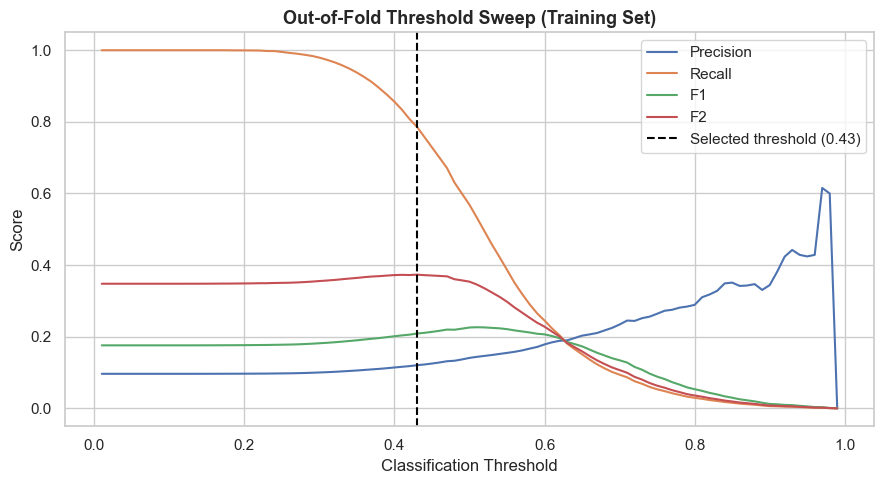

In [40]:
# ----------------------------------------------------------------------
# 6.3 Plot precision, recall, F1, and F2 across candidate thresholds
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
ax.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
ax.plot(threshold_df["Threshold"], threshold_df["F1"], label="F1")
ax.plot(threshold_df["Threshold"], threshold_df["F2"], label="F2")
ax.axvline(SELECTED_THRESHOLD, linestyle="--", color="black", label=f"Selected threshold ({SELECTED_THRESHOLD:.2f})")
ax.set_title("Out-of-Fold Threshold Sweep (Training Set)")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()


# 7. Refit the Tuned Model on the Full Training Set

The tuned pipeline (best hyperparameters from Section 5) is refit once on all 52,829 training patients. This mirrors the baseline notebook's structure: cross-validation for model/threshold selection, then a single refit before touching the test set.


In [15]:
# ----------------------------------------------------------------------
# 7.1 Refit tuned pipeline on the full training partition (timed: Stage 6/12)
# ----------------------------------------------------------------------
with stage_timer(f"Refitting {best_model_name} on the full training set"):
    tuned_model.fit(X_train, y_train)

print(f"{best_model_name} refit on the full training set.")



STAGE 6/12: Refitting Logistic Regression (tuned) on the full training set
Stage 6/12 complete — Refitting Logistic Regression (tuned) on the full training set [0:00:15]
Logistic Regression (tuned) refit on the full training set.


# 8. Held-Out Test Set Evaluation

Evaluated once, on the untouched Phase 2 test set (17,610 patients), at **both** the default 0.50 threshold and the selected threshold from Section 6, so the effect of threshold tuning is visible directly rather than asserted.


In [17]:
# ----------------------------------------------------------------------
# 8.1 Generate test-set predicted probabilities
# ----------------------------------------------------------------------
y_test_prob = tuned_model.predict_proba(X_test)[:, 1]

def evaluate_at_threshold(y_true, y_prob, threshold):
    preds = (y_prob >= threshold).astype(int)
    return {
        "Threshold": threshold,
        "PR-AUC": average_precision_score(y_true, y_prob),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0),
        "Accuracy": accuracy_score(y_true, preds),
    }

results_default = evaluate_at_threshold(y_test, y_test_prob, 0.50)
results_selected = evaluate_at_threshold(y_test, y_test_prob, SELECTED_THRESHOLD)

tuned_test_metrics = pd.DataFrame([results_default, results_selected], index=["Default (0.50)", "Selected (tuned)"])
display(tuned_test_metrics)


,Threshold,PR-AUC,ROC-AUC,Precision,Recall,F1,Accuracy
Default (0.50),0.50,0.108638,0.608032,0.090744,0.541216,0.155428,0.598864
Selected (tuned),0.43,0.108638,0.608032,0.080378,0.786844,0.145856,0.371493


                     precision    recall  f1-score   support

Not readmitted <30d       0.96      0.34      0.50     16409
    Readmitted <30d       0.08      0.79      0.15      1201

           accuracy                           0.37     17610
          macro avg       0.52      0.56      0.32     17610
       weighted avg       0.90      0.37      0.48     17610



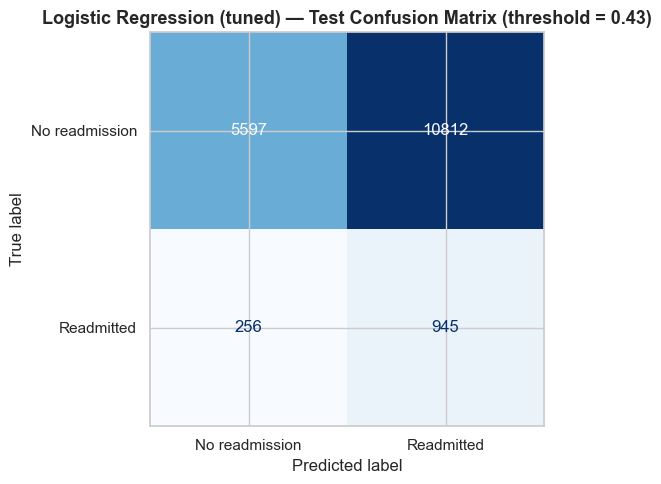

In [41]:
# ----------------------------------------------------------------------
# 8.2 Classification report and confusion matrix at the selected threshold
# ----------------------------------------------------------------------
y_test_pred_selected = (y_test_prob >= SELECTED_THRESHOLD).astype(int)

print(classification_report(
    y_test, y_test_pred_selected,
    target_names=["Not readmitted <30d", "Readmitted <30d"],
    zero_division=0,
))

cm = confusion_matrix(y_test, y_test_pred_selected)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No readmission", "Readmitted"]).plot(
    ax=ax, values_format="d", cmap="Blues", colorbar=False
)
ax.set_title(f"{best_model_name} — Test Confusion Matrix (threshold = {SELECTED_THRESHOLD:.2f})")
plt.tight_layout()
plt.show()


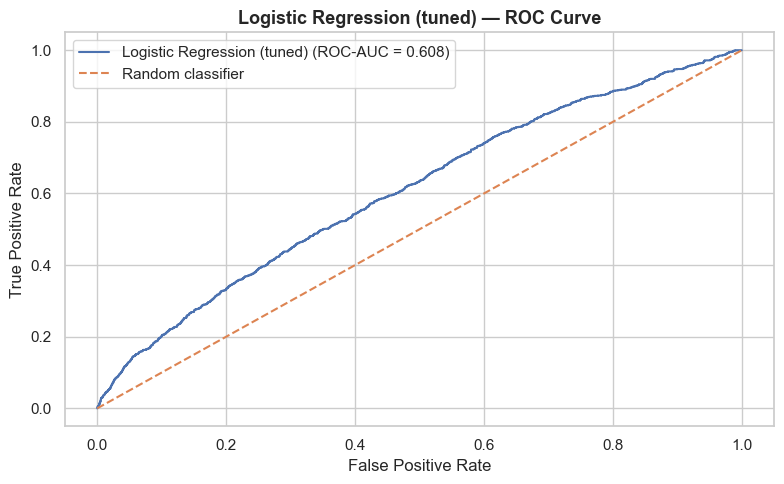

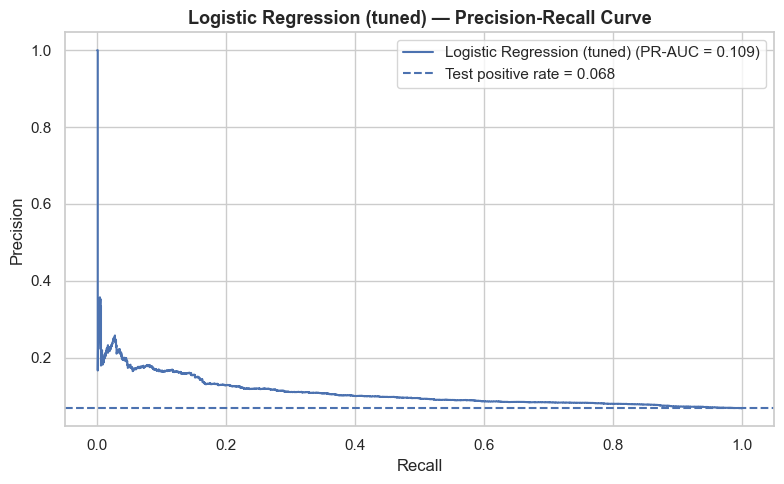

In [42]:
# ----------------------------------------------------------------------
# 8.3 ROC and Precision-Recall curves (threshold-independent views)
# ----------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fpr, tpr, label=f"{best_model_name} (ROC-AUC = {roc_auc_score(y_test, y_test_prob):.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
ax.set_title(f"{best_model_name} — ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
base_rate = y_test.mean()
ax.plot(recall, precision, label=f"{best_model_name} (PR-AUC = {average_precision_score(y_test, y_test_prob):.3f})")
ax.axhline(base_rate, linestyle="--", label=f"Test positive rate = {base_rate:.3f}")
ax.set_title(f"{best_model_name} — Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()


In [20]:
# ----------------------------------------------------------------------
# 8.4 Compare the tuned model directly against the Phase 3 baseline
# ----------------------------------------------------------------------
if baseline_test_metrics is not None:
    baseline_row = baseline_test_metrics.set_index("Metric")["Test Score"] if "Metric" in baseline_test_metrics.columns else None
    print("Baseline (Phase 3) vs. Tuned (Phase 4) test-set metrics:")
    comparison = pd.DataFrame({
        "Baseline (0.50 threshold)": baseline_row if baseline_row is not None else np.nan,
        "Tuned (selected threshold)": pd.Series(results_selected).drop("Threshold"),
    })
    display(comparison)
else:
    print("Baseline metrics file was not found earlier in this notebook; "
          "manually compare against Table 3 of the Baseline Model Report.")


Baseline (Phase 3) vs. Tuned (Phase 4) test-set metrics:


,Baseline (0.50 threshold),Tuned (selected threshold)
PR-AUC,0.108321,0.108638
ROC-AUC,0.604588,0.608032
Precision,0.300000,0.080378
Recall,0.002498,0.786844
F1,0.004955,0.145856
Accuracy,0.931573,0.371493


# 9. Feature Importance for the Tuned Model

Permutation importance is used regardless of model family so that importance is measured consistently (by how much held-out PR-AUC drops when a feature is shuffled) rather than switching interpretation methods between a linear and a tree-based model. This directly follows up on the baseline report's Section 3.5 caution that raw logistic-regression coefficients for rare `medical_specialty` categories may reflect small-sample noise rather than a robust association.


In [21]:
# ----------------------------------------------------------------------
# 9.1 Permutation importance (scored on the test set, PR-AUC scoring)
# ----------------------------------------------------------------------
N_PERM_REPEATS = 10

# permutation_importance parallelizes across features (n_jobs=-1); the
# progress bar below ticks forward once per feature as its repeats finish.
with stage_timer(f"Permutation importance ({len(X_test.columns)} features x {N_PERM_REPEATS} repeats)"):
    with tqdm_joblib(tqdm(total=len(X_test.columns), desc="Permutation importance by feature", unit="feature")):
        perm_result = permutation_importance(
            tuned_model, X_test, y_test,
            scoring="average_precision",
            n_repeats=N_PERM_REPEATS,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

perm_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_SD": perm_result.importances_std,
}).sort_values("Importance_Mean", ascending=False).reset_index(drop=True)

print("Top 15 features by permutation importance (PR-AUC drop when shuffled):")
display(perm_importance_df.head(15))



STAGE 7/12: Permutation importance (49 features x 10 repeats)


Permutation importance by feature: 100%|██████████| 49/49 [00:13<00:00,  3.71feature/s]

Stage 7/12 complete — Permutation importance (49 features x 10 repeats) [0:00:13]
Top 15 features by permutation importance (PR-AUC drop when shuffled):


,Feature,Importance_Mean,Importance_SD
0,A1Cresult,0.022898,0.002105
1,A1Cresult_tested,0.016459,0.001421
2,number_inpatient,0.012822,0.001575
3,age,0.003274,0.000719
4,diag_1_group,0.001612,0.000980
5,number_emergency,0.001473,0.000594
6,num_procedures,0.001079,0.000663
7,diag_3_group,0.000739,0.000315
8,number_diagnoses,0.000669,0.000608
9,admission_source_id_label,0.000660,0.000249


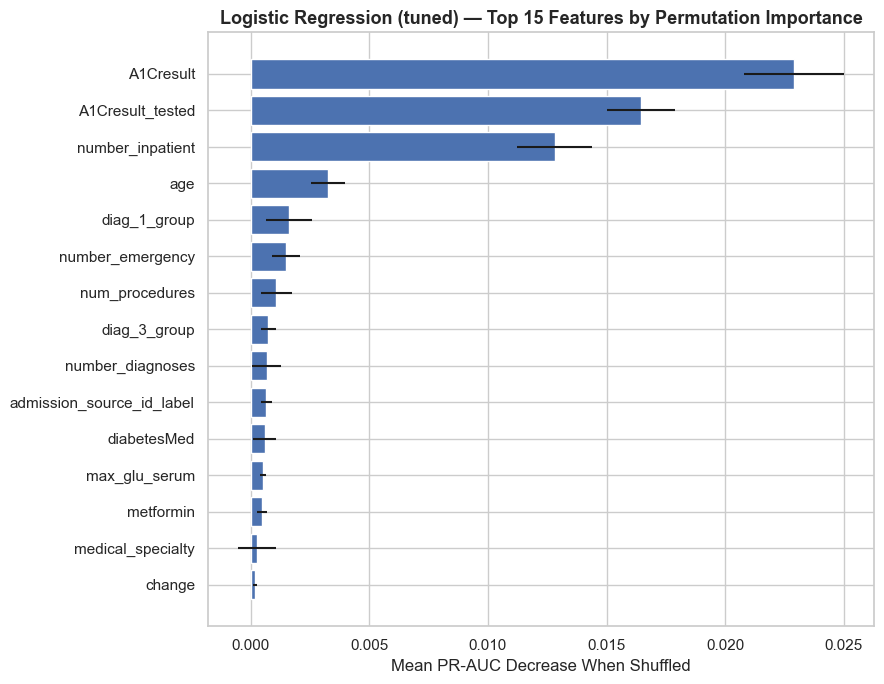

In [43]:
# ----------------------------------------------------------------------
# 9.2 Plot the top permutation-importance features
# ----------------------------------------------------------------------
top_perm = perm_importance_df.head(15).sort_values("Importance_Mean")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_perm["Feature"], top_perm["Importance_Mean"], xerr=top_perm["Importance_SD"])
ax.set_title(f"{best_model_name} — Top 15 Features by Permutation Importance")
ax.set_xlabel("Mean PR-AUC Decrease When Shuffled")
plt.tight_layout()
plt.show()


# 10. Unsupervised Model 1: K-Means Clustering for Patient Risk Segmentation

This is exploratory analysis, not part of the production pipeline. The goal is to check whether patients naturally group into segments based on utilization and treatment-intensity features, and whether any segment shows a materially different 30-day readmission rate, which would be useful context for care-management targeting even outside the supervised model's individual risk scores.

Clustering is run on the **training partition only**, using a feature subset chosen for clinical interpretability (age, number of medications, time in hospital, prior-utilization counts, and diagnosis grouping), rather than the full one-hot-encoded modeling matrix, so that resulting clusters remain describable in plain terms to a care team.


In [23]:
# ----------------------------------------------------------------------
# 10.1 Select and prepare clustering features
# ----------------------------------------------------------------------
CLUSTER_NUMERIC_FEATURES = [
    "time_in_hospital", "num_medications", "num_lab_procedures", "num_procedures",
    "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses",
]
CLUSTER_CATEGORICAL_FEATURES = ["age", "diag_1_group"]

cluster_input_train = train_df[CLUSTER_NUMERIC_FEATURES + CLUSTER_CATEGORICAL_FEATURES].copy()

cluster_preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), CLUSTER_NUMERIC_FEATURES),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="Missing")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CLUSTER_CATEGORICAL_FEATURES),
])

cluster_matrix_train = cluster_preprocessor.fit_transform(cluster_input_train)
print(f"Clustering feature matrix shape: {cluster_matrix_train.shape}")


Clustering feature matrix shape: (52829, 28)



STAGE 14/12: K-means: sweeping k = 2..8 (elbow + silhouette)


Fitting K-means per candidate k:  14%|█▍        | 1/7 [00:00<00:05,  1.07k/s]

k=2: inertia=440,784, silhouette (sampled)=0.1797


Fitting K-means per candidate k:  29%|██▊       | 2/7 [00:02<00:05,  1.07s/k]

k=3: inertia=405,166, silhouette (sampled)=0.1749


...

k=6: inertia=329,530, silhouette (sampled)=0.1251


Fitting K-means per candidate k:  86%|████████▌ | 6/7 [00:08<00:01,  1.51s/k]

k=7: inertia=314,506, silhouette (sampled)=0.1218


Fitting K-means per candidate k: 100%|██████████| 7/7 [00:09<00:00,  1.43s/k]

k=8: inertia=293,911, silhouette (sampled)=0.1256
Stage 14/12 complete — K-means: sweeping k = 2..8 (elbow + silhouette) [0:00:10]


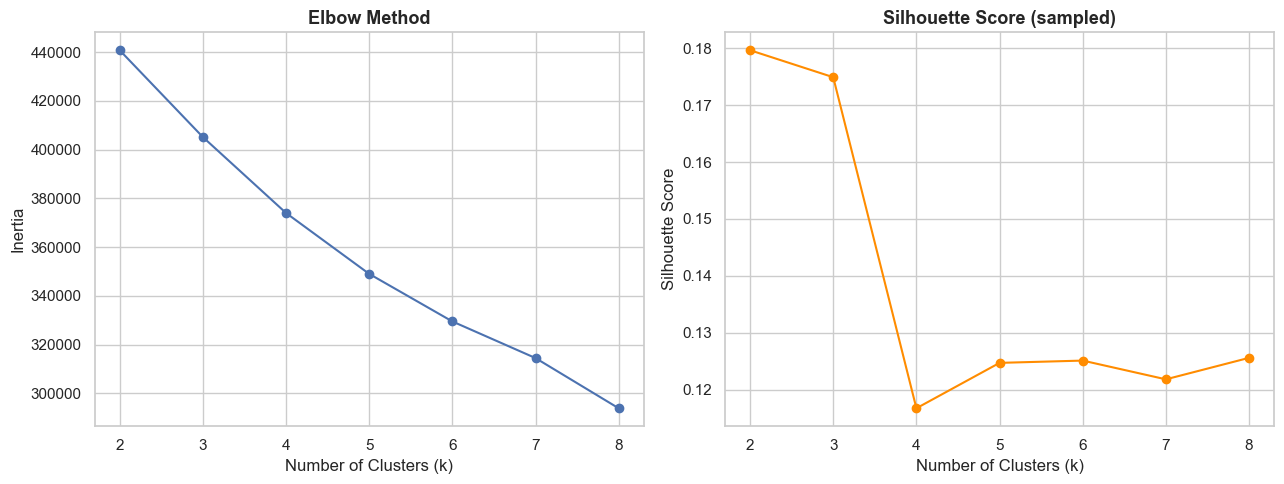

In [44]:
# ----------------------------------------------------------------------
# 10.2 Choose k using the elbow method and silhouette score (timed: Stage 7/12)
# ----------------------------------------------------------------------
k_candidates = range(2, 9)
inertia_values = []
silhouette_values = []

# Silhouette scoring on the full training matrix is expensive at this row count;
# a random subsample is used for the silhouette check only (not for fitting).
SILHOUETTE_SAMPLE_SIZE = 5000
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(cluster_matrix_train.shape[0], size=min(SILHOUETTE_SAMPLE_SIZE, cluster_matrix_train.shape[0]), replace=False)

with stage_timer(f"K-means: sweeping k = {min(k_candidates)}..{max(k_candidates)} (elbow + silhouette)"):
    for k in tqdm(list(k_candidates), desc="Fitting K-means per candidate k", unit="k"):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(cluster_matrix_train)
        inertia_values.append(km.inertia_)
        sil_score = silhouette_score(cluster_matrix_train[sample_idx], labels[sample_idx])
        silhouette_values.append(sil_score)
        print(f"k={k}: inertia={km.inertia_:,.0f}, silhouette (sampled)={sil_score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(k_candidates), inertia_values, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_candidates), silhouette_values, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score (sampled)")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()


In [25]:
# ----------------------------------------------------------------------
# 10.3 Fit K-means with the selected k (timed: Stage 8/12)
# ----------------------------------------------------------------------
# Set based on the elbow/silhouette plot above; update this value after reviewing the plot.
SELECTED_K = 4

with stage_timer(f"K-means: fitting final model with k={SELECTED_K}"):
    kmeans_model = KMeans(n_clusters=SELECTED_K, random_state=RANDOM_STATE, n_init=10)
    train_df["cluster"] = kmeans_model.fit_predict(cluster_matrix_train)

print(f"K-means fit with k={SELECTED_K}.")
print(train_df["cluster"].value_counts().sort_index())



STAGE 9/12: K-means: fitting final model with k=4
Stage 9/12 complete — K-means: fitting final model with k=4 [0.25s]
K-means fit with k=4.
cluster
0    10384
1    21127
2    18458
3     2860
Name: count, dtype: int64


In [26]:
# ----------------------------------------------------------------------
# 10.4 Cluster profiling: mean feature values per cluster
# ----------------------------------------------------------------------
cluster_profile = train_df.groupby("cluster")[CLUSTER_NUMERIC_FEATURES].mean().round(2)
cluster_profile["n_patients"] = train_df["cluster"].value_counts().sort_index()
display(cluster_profile)


,time_in_hospital,num_medications,num_lab_procedures,num_procedures,number_outpatient,number_emergency,number_inpatient,number_diagnoses,n_patients
cluster,,,,,,,,,
0,8.08,25.54,55.99,3.20,0.16,0.05,0.11,7.91,10384
1,3.78,13.94,41.75,0.86,0.25,0.07,0.09,8.40,21127
2,2.91,11.47,36.88,1.09,0.13,0.04,0.06,4.76,18458
3,4.73,16.20,49.78,1.13,1.49,0.81,2.07,7.80,2860


Overall training-set readmission rate: 0.0964


,time_in_hospital,num_medications,num_lab_procedures,num_procedures,number_outpatient,number_emergency,number_inpatient,number_diagnoses,n_patients,readmission_rate
cluster,,,,,,,,,,
3,4.73,16.20,49.78,1.13,1.49,0.81,2.07,7.80,2860,0.1958
0,8.08,25.54,55.99,3.20,0.16,0.05,0.11,7.91,10384,0.1150
1,3.78,13.94,41.75,0.86,0.25,0.07,0.09,8.40,21127,0.0979
2,2.91,11.47,36.88,1.09,0.13,0.04,0.06,4.76,18458,0.0690


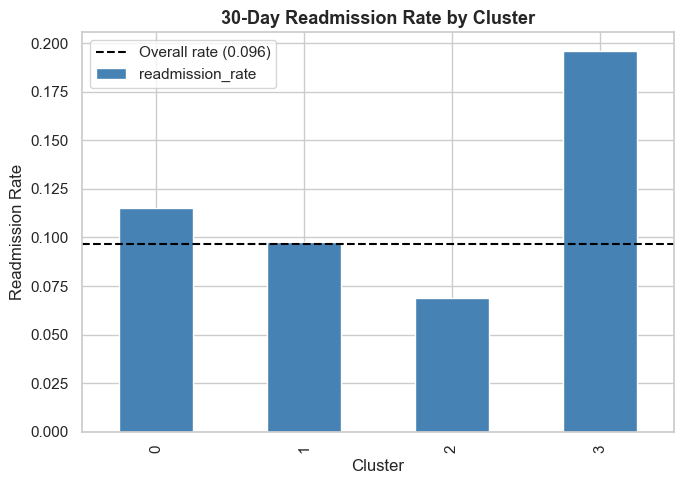

In [45]:
# ----------------------------------------------------------------------
# 10.5 Cross-tabulate cluster assignment against 30-day readmission rate
# ----------------------------------------------------------------------
cluster_readmission_rate = train_df.groupby("cluster")[TARGET].mean().rename("readmission_rate").round(4)
cluster_summary = cluster_profile.join(cluster_readmission_rate)
overall_rate = train_df[TARGET].mean()

print(f"Overall training-set readmission rate: {overall_rate:.4f}")
display(cluster_summary.sort_values("readmission_rate", ascending=False))

fig, ax = plt.subplots(figsize=(7, 5))
cluster_summary["readmission_rate"].sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.axhline(overall_rate, linestyle="--", color="black", label=f"Overall rate ({overall_rate:.3f})")
ax.set_title("30-Day Readmission Rate by Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Readmission Rate")
ax.legend()
plt.tight_layout()
plt.show()


# 11. Unsupervised Model 2: Dimensionality Reduction (PCA)

PCA is applied to the same fully preprocessed feature matrix used by the supervised model (all 49 predictors after one-hot encoding), on the training partition only, to check (a) how much of the variance in the engineered feature set is concentrated in a small number of components, and (b) whether patients visually separate by readmission status or cluster assignment in a low-dimensional projection. A t-SNE view is included as a secondary, non-linear visualization, since PCA is a linear technique that can miss non-linear structure.

Per the assignment scope, this is exploratory: it is not used to replace the modeling features in Section 5 unless the variance-explained and separation results below justify it, in which case that would be proposed as a follow-up feature-engineering change, not applied silently here.


In [28]:
# ----------------------------------------------------------------------
# 11.1 Fit PCA on the preprocessed modeling feature matrix (timed: Stage 9/12)
# ----------------------------------------------------------------------
with stage_timer("PCA: fitting on the preprocessed feature matrix"):
    pca_feature_matrix_train = preprocessor.fit_transform(X_train)

    # PCA requires a dense array; the one-hot-encoded matrix is sparse, so it is
    # densified here. This is fine at this feature-matrix width but would need a
    # sparse-aware approach (e.g. TruncatedSVD) if the feature count grows much larger.
    if hasattr(pca_feature_matrix_train, "toarray"):
        pca_feature_matrix_train = pca_feature_matrix_train.toarray()

    pca_model = PCA(n_components=20, random_state=RANDOM_STATE)
    pca_scores_train = pca_model.fit_transform(pca_feature_matrix_train)

explained_variance = pca_model.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_variance_df = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained_Variance_Ratio": explained_variance,
    "Cumulative_Variance": cumulative_variance,
})
display(pca_variance_df)



STAGE 10/12: PCA: fitting on the preprocessed feature matrix
Stage 10/12 complete — PCA: fitting on the preprocessed feature matrix [0.48s]


,Component,Explained_Variance_Ratio,Cumulative_Variance
0,PC1,0.104189,0.104189
1,PC2,0.081326,0.185515
2,PC3,0.074134,0.259648
3,PC4,0.058515,0.318164
4,PC5,0.048520,0.366684
5,PC6,0.046228,0.412912
6,PC7,0.043116,0.456029
7,PC8,0.040441,0.496470
8,PC9,0.037409,0.533878
9,PC10,0.032859,0.566737


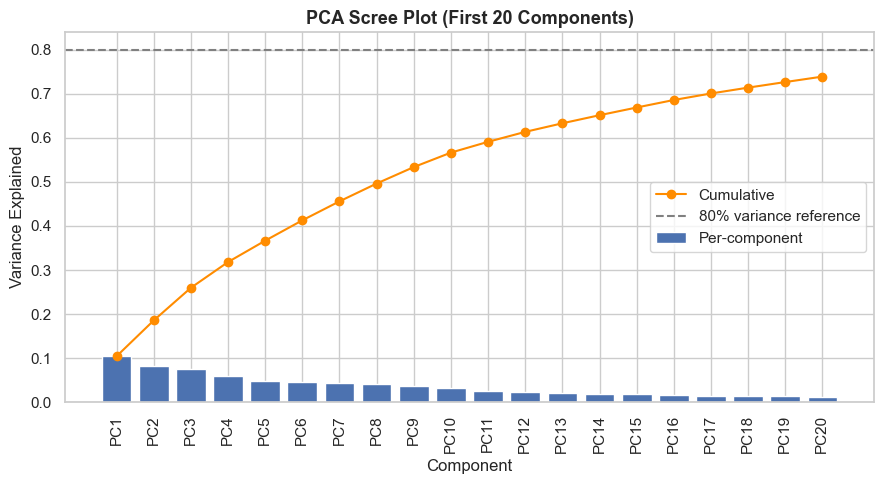

Note: the first 20 components only reach 73.9% cumulative variance, so PCA is being refit with n_components=0.80 to solve for the true count directly.

STAGE 15/12: PCA: refitting to find components needed for 80% variance
Stage 15/12 complete — PCA: refitting to find components needed for 80% variance [0.22s]
Components needed to reach 80% cumulative variance: 26 (out of 243 original one-hot-encoded columns)


In [46]:
# ----------------------------------------------------------------------
# 11.2 Scree plot: variance explained per component and cumulatively
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(pca_variance_df["Component"], pca_variance_df["Explained_Variance_Ratio"], label="Per-component")
ax.plot(pca_variance_df["Component"], pca_variance_df["Cumulative_Variance"], color="darkorange", marker="o", label="Cumulative")
ax.axhline(0.80, linestyle="--", color="gray", label="80% variance reference")
ax.set_title("PCA Scree Plot (First 20 Components)")
ax.set_xlabel("Component")
ax.set_ylabel("Variance Explained")
ax.tick_params(axis="x", rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 11.3 Components needed to reach 80% cumulative variance
# ----------------------------------------------------------------------
# BUG (flagged in the Hyperparameter Tuning & Model Evaluation report, Section 3.6):
# the original line here was
#     n_components_80pct = int(np.argmax(cumulative_variance >= 0.80) + 1)
# np.argmax() on a boolean array that is all False (which is what happens, since the
# 20 fitted components only reach ~74% cumulative variance) silently returns index 0,
# so this reported "1 component reaches 80% variance," which is false and directly
# contradicted the cumulative-variance table printed just above it.
#
# FIX: check whether 80% is actually reached within the fitted components first.
# If it is, the same argmax logic is safe to use, since the condition is true somewhere.
# If it is not, PCA is refit with n_components=0.80, which tells scikit-learn to solve
# directly for the minimum number of components that explain at least 80% of variance,
# instead of guessing from a truncated array.
if cumulative_variance.max() >= 0.80:
    n_components_80pct = int(np.argmax(cumulative_variance >= 0.80) + 1)
else:
    print(
        f"Note: the first {len(cumulative_variance)} components only reach "
        f"{cumulative_variance.max():.1%} cumulative variance, so PCA is being refit "
        f"with n_components=0.80 to solve for the true count directly."
    )
    with stage_timer("PCA: refitting to find components needed for 80% variance"):
        pca_model_80pct = PCA(n_components=0.80, random_state=RANDOM_STATE)
        pca_model_80pct.fit(pca_feature_matrix_train)
    n_components_80pct = pca_model_80pct.n_components_

print(f"Components needed to reach 80% cumulative variance: {n_components_80pct} (out of {pca_feature_matrix_train.shape[1]} original one-hot-encoded columns)")


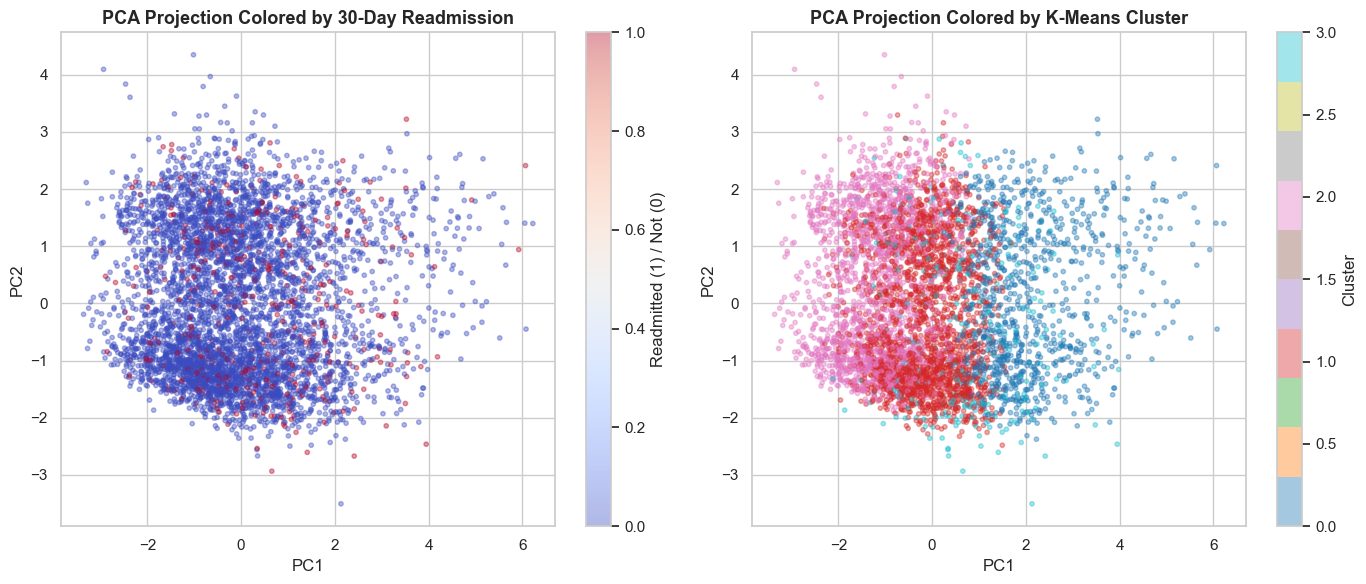

In [50]:
# ----------------------------------------------------------------------
# 11.3 2D PCA scatter, colored by readmission status and by cluster
# ----------------------------------------------------------------------
# Plotting the full training set is expensive and visually overplotted;
# a random subsample is used for these two visualizations only.
PLOT_SAMPLE_SIZE = 5000
plot_idx = rng.choice(pca_scores_train.shape[0], size=min(PLOT_SAMPLE_SIZE, pca_scores_train.shape[0]), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(
    pca_scores_train[plot_idx, 0], pca_scores_train[plot_idx, 1],
    c=y_train.values[plot_idx], cmap="coolwarm", alpha=0.4, s=10
)
axes[0].set_title("PCA Projection Colored by 30-Day Readmission")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(scatter1, ax=axes[0], label="Readmitted (1) / Not (0)")

scatter2 = axes[1].scatter(
    pca_scores_train[plot_idx, 0], pca_scores_train[plot_idx, 1],
    c=train_df["cluster"].values[plot_idx], cmap="tab10", alpha=0.4, s=10
)
axes[1].set_title("PCA Projection Colored by K-Means Cluster")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(scatter2, ax=axes[1], label="Cluster")

plt.tight_layout()
plt.show()



STAGE 17/12: t-SNE: fitting non-linear projection on the sampled patients
Stage 17/12 complete — t-SNE: fitting non-linear projection on the sampled patients [0:00:22]


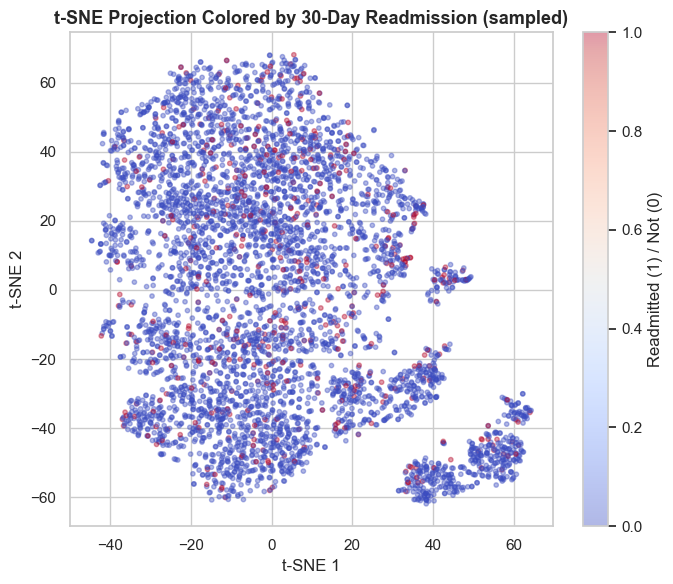

In [49]:
# ----------------------------------------------------------------------
# 11.4 Optional: t-SNE view (non-linear) on the same subsample (timed: Stage 10/12)
# ----------------------------------------------------------------------
# t-SNE is run on the same subsample used above, since it does not scale to the
# full training set. It is a supplementary visualization, not a modeling input.
with stage_timer("t-SNE: fitting non-linear projection on the sampled patients"):
    tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init="pca")
    tsne_scores = tsne.fit_transform(pca_feature_matrix_train[plot_idx])

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    tsne_scores[:, 0], tsne_scores[:, 1],
    c=y_train.values[plot_idx], cmap="coolwarm", alpha=0.4, s=10
)
ax.set_title("t-SNE Projection Colored by 30-Day Readmission (sampled)")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.colorbar(scatter, ax=ax, label="Readmitted (1) / Not (0)")
plt.tight_layout()
plt.show()


In [34]:
# ----------------------------------------------------------------------
# 11.5 Correlation of the leading principal components with the target
# ----------------------------------------------------------------------
# This checks whether the top components carry target-relevant signal on their
# own merit, as a first read on whether they would be worth proposing as
# engineered features in a future feature-engineering pass.
pc_target_corr = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(10)],
    "Correlation_with_target": [np.corrcoef(pca_scores_train[:, i], y_train)[0, 1] for i in range(10)],
}).sort_values("Correlation_with_target", key=np.abs, ascending=False)

display(pc_target_corr)


,Component,Correlation_with_target
0,PC1,0.070611
3,PC4,0.058531
7,PC8,0.050913
2,PC3,0.041774
5,PC6,0.039044
1,PC2,-0.030872
4,PC5,-0.026855
6,PC7,-0.021787
8,PC9,0.015639
9,PC10,0.006703


# 12. Summary for the Written Report

Use the cells below to produce report-ready numbers. Values are generated directly from the objects fit above, not manually entered.


In [35]:
# ----------------------------------------------------------------------
# 12.1 Supervised model summary table
# ----------------------------------------------------------------------
supervised_summary = pd.DataFrame({
    "Item": [
        "Selected model family",
        "Selected hyperparameters",
        "Best CV PR-AUC (training only)",
        "Selected classification threshold",
        "Test PR-AUC (selected threshold)",
        "Test ROC-AUC (selected threshold)",
        "Test Precision (selected threshold)",
        "Test Recall (selected threshold)",
        "Test F1 (selected threshold)",
        "Test Accuracy (selected threshold)",
    ],
    "Value": [
        best_model_name,
        str(best_search.best_params_),
        f"{best_search.best_score_:.4f}",
        f"{SELECTED_THRESHOLD:.2f}",
        f"{results_selected['PR-AUC']:.4f}",
        f"{results_selected['ROC-AUC']:.4f}",
        f"{results_selected['Precision']:.4f}",
        f"{results_selected['Recall']:.4f}",
        f"{results_selected['F1']:.4f}",
        f"{results_selected['Accuracy']:.4f}",
    ],
})
display(supervised_summary)


,Item,Value
0,Selected model family,Logistic Regression (tuned)
1,Selected hyperparameters,"{'model__penalty': 'l1', 'model__class_weight'..."
2,Best CV PR-AUC (training only),0.1603
3,Selected classification threshold,0.43
4,Test PR-AUC (selected threshold),0.1086
5,Test ROC-AUC (selected threshold),0.6080
6,Test Precision (selected threshold),0.0804
7,Test Recall (selected threshold),0.7868
8,Test F1 (selected threshold),0.1459
9,Test Accuracy (selected threshold),0.3715


In [36]:
# ----------------------------------------------------------------------
# 12.2 Unsupervised summary
# ----------------------------------------------------------------------
unsupervised_summary = pd.DataFrame({
    "Item": [
        "K-means: selected k",
        "K-means: cluster with highest readmission rate",
        "K-means: highest cluster readmission rate",
        "K-means: overall training readmission rate",
        "PCA: components fit",
        "PCA: components to reach 80% cumulative variance",
        "PCA: PC1 explained variance ratio",
    ],
    "Value": [
        SELECTED_K,
        int(cluster_summary["readmission_rate"].idxmax()),
        f"{cluster_summary['readmission_rate'].max():.4f}",
        f"{overall_rate:.4f}",
        pca_model.n_components,
        n_components_80pct,
        f"{explained_variance[0]:.4f}",
    ],
})
display(unsupervised_summary)


,Item,Value
0,K-means: selected k,4
1,K-means: cluster with highest readmission rate,3
2,K-means: highest cluster readmission rate,0.1958
3,K-means: overall training readmission rate,0.0964
4,PCA: components fit,20
5,PCA: components to reach 80% cumulative variance,26
6,PCA: PC1 explained variance ratio,0.1042


# 13. Next Steps

1. Register the selected tuned model (Section 5) and its selected threshold (Section 6) in MLflow.
2. Build the FastAPI endpoint around the tuned pipeline; the two unsupervised models remain exploratory and are not served.
3. If the PCA correlation check (Section 11.5) shows components with a meaningfully strong target correlation, propose adding the top components as engineered features in a follow-up pass, rather than folding them in silently.
4. If a cluster's readmission rate is materially and consistently above the overall rate (Section 10.5), share that segmentation with the care-management stakeholder audience as a targeting input, separate from individual model risk scores.
5. Document any features flagged as unstable in Section 9's permutation importance for review before the model is finalized for deployment.


# 14. Save the Tuned Model and Results

Both the tuned supervised pipeline and the two unsupervised models are saved, since the unsupervised models remain useful analysis artifacts even though they are not served in production.


In [37]:
# ----------------------------------------------------------------------
# 14.1 Save all model artifacts and report tables (timed: Stage 12/12)
# ----------------------------------------------------------------------
# `joblib` and `time` were already imported in Section 1.2 (progress/timing utilities).
OUTPUT_DIR_CANDIDATES = ["../outputs", "outputs"]
OUTPUT_DIR = next((p for p in OUTPUT_DIR_CANDIDATES if os.path.exists(p)), OUTPUT_DIR_CANDIDATES[0])
os.makedirs(OUTPUT_DIR, exist_ok=True)

with stage_timer("Saving model artifacts and report tables"):
    joblib.dump(tuned_model, os.path.join(OUTPUT_DIR, "tuned_supervised_model.joblib"))
    joblib.dump(kmeans_model, os.path.join(OUTPUT_DIR, "kmeans_model.joblib"))
    joblib.dump(pca_model, os.path.join(OUTPUT_DIR, "pca_model.joblib"))

    model_comparison.to_csv(os.path.join(OUTPUT_DIR, "model_family_comparison.csv"), index=False)
    tuned_test_metrics.to_csv(os.path.join(OUTPUT_DIR, "tuned_test_metrics.csv"))
    perm_importance_df.to_csv(os.path.join(OUTPUT_DIR, "tuned_permutation_importance.csv"), index=False)
    cluster_summary.to_csv(os.path.join(OUTPUT_DIR, "cluster_summary.csv"))
    pca_variance_df.to_csv(os.path.join(OUTPUT_DIR, "pca_variance.csv"), index=False)
    pc_target_corr.to_csv(os.path.join(OUTPUT_DIR, "pca_target_correlation.csv"), index=False)
    supervised_summary.to_csv(os.path.join(OUTPUT_DIR, "supervised_summary.csv"), index=False)
    unsupervised_summary.to_csv(os.path.join(OUTPUT_DIR, "unsupervised_summary.csv"), index=False)

print(f"All artifacts saved to {OUTPUT_DIR}/")

# ----------------------------------------------------------------------
# 14.2 Total notebook runtime
# ----------------------------------------------------------------------
# Not a numbered stage on its own -- just a summary of all 12 stages above.
# Reported for planning purposes: this is roughly how long a fresh,
# end-to-end run of this notebook takes on this machine, which is useful
# context when this pipeline is later scheduled as a recurring Airflow job.
total_elapsed = time.time() - NOTEBOOK_START_TIME
print(f"\nAll 12 stages complete. Total notebook runtime: {format_elapsed(total_elapsed)}")



STAGE 13/12: Saving model artifacts and report tables
Stage 13/12 complete — Saving model artifacts and report tables [0.02s]
All artifacts saved to outputs/

All 12 stages complete. Total notebook runtime: 1:10:46


In [39]:
# ----------------------------------------------------------------------
# Auto-save every figure to 04_outputs/ at the moment it's shown
# ----------------------------------------------------------------------
# Jupyter's inline backend closes each figure immediately after plt.show()
# displays it, so a "save everything at the end" cell finds nothing left
# in memory. This patches plt.show() itself to save a copy first, so every
# figure gets written to disk the moment it's created, regardless of when
# the notebook is stopped or how many cells are re-run.
import os
figures_dir = "04_outputs"
os.makedirs(figures_dir, exist_ok=True)

_fig_counter = {"n": 0}
_original_show = plt.show

def _show_and_save(*args, **kwargs):
    _fig_counter["n"] += 1
    fig = plt.gcf()

    title = fig._suptitle.get_text() if fig._suptitle else None
    if not title and fig.axes:
        title = fig.axes[0].get_title()
    if not title:
        title = f"figure_{_fig_counter['n']}"

    safe_name = "".join(c if c.isalnum() or c in (" ", "_", "-") else "" for c in title)
    safe_name = safe_name.strip().replace(" ", "_").lower()

    filepath = os.path.join(figures_dir, f"{_fig_counter['n']:02d}_{safe_name}.png")
    fig.savefig(filepath, dpi=200, bbox_inches="tight")

    return _original_show(*args, **kwargs)

plt.show = _show_and_save
print(f"Figures will now auto-save to {figures_dir}/ as they're created.")

Figures will now auto-save to 04_outputs/ as they're created.


# End of Notebook 4

**Primary deliverables:** tuned supervised classifier (hyperparameter search across logistic regression, random forest, and XGBoost) with a data-driven classification threshold and full test-set evaluation, plus two exploratory unsupervised analyses (K-means patient segmentation and PCA/t-SNE dimensionality reduction).

**GitHub:** https://github.com/AngelineSetiawan/AngelineSetiawan-hospital-readmission-risk-predictor
